# TP optimisation — Exercice 3 : clustering par optimisation des centroïdes




In [1]:
import os
print("Dossier de travail (cwd) :", os.getcwd())

Dossier de travail (cwd) : c:\Users\lenovo\Desktop\HADRI


## 1. Configuration (modifiable)
Les fichiers de données doivent être dans `data/` (voir notebook `00_donnees`).

In [ ]:
from pathlib import Path
DATA_DIR = next((str(p) for p in [Path("data"), Path("../data")] if p.exists()), "data")
print("Données lues dans :", os.path.abspath(DATA_DIR))
IMAGES = [d for d, f in [("mnist", "mnist_50k_10k_10k.npz"), ("fashion", "fashion_mnist_50k_10k_10k.npz")] if os.path.exists(os.path.join(DATA_DIR, f))]
if len(IMAGES) < 2: print("ATTENTION : fichiers images manquants, jeux ignorés :", {"mnist", "fashion"} - set(IMAGES), "-> exécuter 00_donnees")

from types import SimpleNamespace
args = SimpleNamespace(data=DATA_DIR, out="results",
    datasets=["blobs", "wine"] + IMAGES,
    epochs_csv=100,
    epochs_img=8,        
    fast=None)

Données lues dans : c:\Users\lenovo\Desktop\HADRI\data


## 2. Code commun : les 7 optimiseurs (NumPy), vérification de gradient, utilitaires

In [ ]:
"""Outils communs aux 3 exercices : les 7 méthodes d'optimisation (NumPy pur),
vérification de gradient, chargement de données, tableaux LaTeX, ACP."""
import os, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

METHODS = ["GD", "GD+recherche", "SGD", "Momentum", "AdaGrad", "RMSprop", "Adam"]
COLORS = {"GD": "tab:blue", "GD+recherche": "tab:cyan", "SGD": "tab:orange",
          "Momentum": "tab:green", "AdaGrad": "tab:red", "RMSprop": "tab:purple",
          "Adam": "black", "Lloyd (réf.)": "tab:brown"}
FULL_BATCH = ("GD", "GD+recherche")          
MU = RHO = B1 = 0.9
B2 = 0.999
EPS = 1e-8
SEEDS = [42, 123, 2024]



def line_search_numeric(loss_fn, theta, g, eta_max, n=12):
    """Recherche directionnelle bornée et approchée : on teste eta_max/2^k
    (k=0..n-1) le long de -g et on garde le pas de plus petite perte."""
    best_eta, best = eta_max / 2 ** (n - 1), np.inf
    l0, calls, eta = loss_fn(theta), 1, eta_max
    best = l0
    found = False
    for _ in range(n):
        l = loss_fn(theta - eta * g)
        calls += 1
        if np.isfinite(l) and l < best:
            best, best_eta, found = l, eta, True
        eta /= 2
    return best_eta, calls


def run_optimizer(method, theta0, grad_fn, loss_fn, n, eta, epochs, batch_size, seed,
                  eval_fn, select_key, hvp=None, eta_max=5.0):
    """Boucle d'entraînement commune.
    grad_fn(theta, idx) et loss_fn(theta, idx=None) : idx=None <=> tout le jeu.
    eval_fn(theta) -> dict de métriques (contient select_key, à minimiser).
    hvp(g) : produit Hessienne-vecteur (pas exact pour les objectifs quadratiques)."""
    rng = np.random.default_rng(seed)
    theta = theta0.copy()
    m = np.zeros_like(theta); s = np.zeros_like(theta); v = np.zeros_like(theta)
    t = 0
    cnt = dict(updates=0, grad_calls=0, loss_calls=0, hvp_calls=0)
    hist, ttrain, diverged = [], 0.0, False
    best_val, best_theta, best_ep = np.inf, theta.copy(), 0
    with np.errstate(all="ignore"):
        for ep in range(1, epochs + 1):
            t0 = time.perf_counter()
            if method in FULL_BATCH:
                batches = [None]
            else:
                perm = rng.permutation(n)
                batches = [perm[i:i + batch_size] for i in range(0, n, batch_size)]
            for idx in batches:
                g = grad_fn(theta, idx); cnt["grad_calls"] += 1
                t += 1; cnt["updates"] += 1
                if method == "GD" or method == "SGD":
                    theta = theta - eta * g
                elif method == "GD+recherche":
                    step = None
                    if hvp is not None:
                        d = g @ hvp(g); cnt["hvp_calls"] += 1
                        if d > 0:
                            step = (g @ g) / d          
                    if step is None:
                        step, c = line_search_numeric(loss_fn, theta, g, eta_max)
                        cnt["loss_calls"] += c
                    theta = theta - step * g
                elif method == "Momentum":
                    v = MU * v + g
                    theta = theta - eta * v
                elif method == "AdaGrad":
                    s = s + g * g
                    theta = theta - eta * g / (np.sqrt(s) + EPS)
                elif method == "RMSprop":
                    s = RHO * s + (1 - RHO) * g * g
                    theta = theta - eta * g / (np.sqrt(s) + EPS)
                elif method == "Adam":
                    m = B1 * m + (1 - B1) * g
                    s = B2 * s + (1 - B2) * g * g
                    mh, sh = m / (1 - B1 ** t), s / (1 - B2 ** t)
                    theta = theta - eta * mh / (np.sqrt(sh) + EPS)
                else:
                    raise ValueError(method)
            ttrain += time.perf_counter() - t0        
            if not np.isfinite(theta).all():
                diverged = True
                break
            met = dict(eval_fn(theta))
            cnt["loss_calls"] += 2   
            met.update(epoch=ep, time=ttrain, updates=cnt["updates"],
                       grad_calls=cnt["grad_calls"], loss_calls=cnt["loss_calls"])
            hist.append(met)
            if met[select_key] < best_val:
                best_val, best_theta, best_ep = met[select_key], theta.copy(), ep
    return dict(hist=hist, best_value=(np.inf if diverged else best_val),
                best_theta=best_theta, best_epoch=best_ep, time=ttrain,
                diverged=diverged, **cnt)


def gradcheck(loss_fn, grad_fn, theta, ncoord=8, h=1e-5, seed=0):
    """Erreur relative max entre gradient analytique et différences finies
    centrales (h = 1e-5) sur quelques coordonnées (theta en float64)."""
    rng = np.random.default_rng(seed)
    g = grad_fn(theta, None)
    cand = np.where(np.abs(g) > 1e-3 * np.abs(g).max())[0]   
    cand = cand if len(cand) else np.arange(theta.size)  
    idxs = rng.choice(cand, min(ncoord, len(cand)), replace=False)
    errs = []
    for i in idxs:
        e = np.zeros_like(theta); e[i] = h
        num = (loss_fn(theta + e, None) - loss_fn(theta - e, None)) / (2 * h)
        errs.append(abs(num - g[i]) / max(1e-12, abs(num) + abs(g[i])))
    return float(max(errs))


def split_of(df):
    def f(v):
        v = str(v).lower()
        return "train" if v.startswith("tr") else ("val" if v.startswith("va") else "test")
    return df["split"].map(f).values


def find_col(df, candidates, default_last=True):
    for c in candidates:
        if c in df.columns:
            return c
    cols = [c for c in df.columns if c != "split"]
    return cols[-1] if default_last else None


def standardize(X, tr):
    mu, sd = X[tr].mean(0), X[tr].std(0)
    sd = np.where(sd == 0, 1.0, sd)
    return (X - mu) / sd, mu, sd


def pca2(X_fit, X_list):
    """ACP 2D par SVD (ajustée sur X_fit). Retourne les projections de X_list."""
    mu = X_fit.mean(0)
    _, _, Vt = np.linalg.svd(X_fit - mu, full_matrices=False)
    return [(X - mu) @ Vt[:2].T for X in X_list]


def ensure_dirs(out):
    os.makedirs(os.path.join(out, "figures"), exist_ok=True)


def savefig(fig, out, name):
    fig.tight_layout()
    fig.savefig(os.path.join(out, "figures", name + ".png"), dpi=130)
    plt.close(fig)


def ms(vals, dec=3):
    v = np.asarray(vals, float)
    return f"{v.mean():.{dec}f} $\\pm$ {v.std():.{dec}f}"


def tex_escape(s):
    s = str(s).replace("_", "\\_").replace("%", "\\%").replace("&", "\\&").replace("#", "\\#")
    for u, m in {"η": "$\\eta$", "λ": "$\\lambda$", "σ": "$\\sigma$", "τ": "$\\tau$"}.items():
        s = s.replace(u, m)
    return s


def df_to_latex(df, path):
    lines = ["\\resizebox{\\textwidth}{!}{%", "\\begin{tabular}{" + "l" * len(df.columns) + "}",
             "\\hline", " & ".join(tex_escape(c) for c in df.columns) + " \\\\", "\\hline"]
    for _, r in df.iterrows():
        lines.append(" & ".join(tex_escape(x) for x in r) + " \\\\")
    lines += ["\\hline", "\\end{tabular}}"]
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))


def load_npz_images(path, fast=None):
    d = np.load(path)
    out = {}
    for k in ["train", "val", "test"]:
        x = d["x_" + k].reshape(len(d["x_" + k]), -1)
        y = d["y_" + k].astype(np.int64).ravel()
        if fast and k == "train":
            x, y = x[:fast], y[:fast]
        out[k] = (x, y)
    return out

FASHION = ["T-shirt", "Pantalon", "Pull", "Robe", "Manteau", "Sandale",
           "Chemise", "Basket", "Sac", "Bottine"]

import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

## Définitions (modèles, gradients, données)

In [ ]:
"""Exercice 3 : clustering par descente sur J_tau(C) (+ Lloyd en référence)."""
import os, time
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

ensure_dirs(args.out)
FILES = {"blobs": "clustering_blobs3.csv", "wine": "clustering_wine.csv",
         "mnist": "mnist_50k_10k_10k.npz", "fashion": "fashion_mnist_50k_10k_10k.npz"}
GRIDS = {"GD": [0.03, 0.1, 0.3, 0.9], "SGD": [0.03, 0.1, 0.3, 0.9], "Momentum": [0.003, 0.01, 0.03, 0.1],
         "AdaGrad": [0.01, 0.03, 0.1, 0.3], "RMSprop": [0.003, 0.01, 0.03, 0.1],
         "Adam": [0.003, 0.01, 0.03, 0.1], "GD+recherche": [None]}


def logsumexp(A, axis=1):
    m = A.max(axis=axis, keepdims=True)
    return (m + np.log(np.exp(A - m).sum(axis=axis, keepdims=True))).squeeze(axis)


def sqdist(X, C):
    """||x||^2 + ||c||^2 - 2 x.c : pas de tableau n x K x d."""
    return np.maximum((X ** 2).sum(1)[:, None] + (C ** 2).sum(1)[None] - 2 * X @ C.T, 0)


def J_tau(C, X, tau):
    K = len(C)
    return float(-tau * np.mean(logsumexp(-sqdist(X, C) / tau) - np.log(K)))


def grad_C(C, X, tau):
    D = sqdist(X, C); A = -D / tau
    Q = np.exp(A - logsumexp(A)[:, None])                       
    return 2 / len(X) * (Q.sum(0)[:, None] * C - Q.T @ X)


def load(name):
    path = os.path.join(args.data, FILES[name])
    if name in ("blobs", "wine"):
        df = pd.read_csv(path); lab = df["true_label"].values
        feats = [c for c in df.columns if c not in ("true_label", "split")]
        X = df[feats].values.astype(float)
        X = (X - X.mean(0)) / np.where(X.std(0) == 0, 1, X.std(0))     
        return dict(train=X, val=X, test=X), lab, 3, 0.25, np.float64
    d = load_npz_images(path, args.fast)
    X = {k: d[k][0].astype(np.float32) / 255 for k in d}
    return X, d["test"][1], 10, 5.0, np.float32


def evaluate(C, Xe, ye, tau):
    D = sqdist(Xe, C); lab = D.argmin(1)
    sil = "N/A"
    idx = np.random.default_rng(0).choice(len(Xe), min(1000, len(Xe)), replace=False)
    if 2 <= len(np.unique(lab[idx])) <= len(idx) - 1:
        sil = float(silhouette_score(Xe[idx].astype(float), lab[idx]))
    return dict(J=J_tau(C, Xe, tau), inertie=float(D.min(1).mean()), nonvides=len(np.unique(lab)),
                silhouette=sil, ari=adjusted_rand_score(ye, lab), nmi=normalized_mutual_info_score(ye, lab)), lab


def init_C(X, K, seed):
    return X[np.random.default_rng(seed).choice(len(X), K, replace=False)].copy()   


def lloyd(C0, Xtr, Xva, tau, iters):
    C, hist, t_tot, calls = C0.copy(), [], 0.0, 0
    for it in range(1, iters + 1):
        t0 = time.perf_counter()
        lab = sqdist(Xtr, C).argmin(1); Cn = C.copy()
        for k in range(len(C)):
            if (lab == k).any(): Cn[k] = Xtr[lab == k].mean(0)          
        t_tot += time.perf_counter() - t0; calls += 1
        moved = np.abs(Cn - C).max() > 1e-9; C = Cn
        hist.append(dict(epoch=it, val_loss=J_tau(C, Xva, tau), time=t_tot))
        if not moved: break
    return dict(hist=hist, best_theta=C.ravel(), best_epoch=len(hist), time=t_tot, updates=len(hist),
                grad_calls=0, loss_calls=0, best_value=hist[-1]["val_loss"], diverged=False)

## Entraînement, évaluation et figures (par jeu de données)

In [ ]:
rows, gc_rows = [], []
for name in args.datasets:
    X, ylab, K, tau, dt = load(name); img = name in ("mnist", "fashion")
    Xtr, Xva, Xte = X["train"], X["val"], X["test"]; d = Xtr.shape[1]
    epochs, bs = (args.epochs_img, 2048) if img else (args.epochs_csv, 64)
    C0g = init_C(Xtr[:200].astype(float), K, 0)
    gc_rows.append(dict(jeu=name, err_rel_max=f"{gradcheck(lambda t, i: J_tau(t.reshape(K, d), Xtr[:200].astype(float), tau), lambda t, i: grad_C(t.reshape(K, d), Xtr[:200].astype(float), tau).ravel(), C0g.ravel(), ncoord=20):.2e}"))
    print(name, "gradcheck", gc_rows[-1]["err_rel_max"], flush=True)

    def run(method, eta, seed):
        C0 = init_C(Xtr, K, seed).astype(dt)                  
        gf = lambda th, idx: grad_C(th.reshape(K, d), Xtr if idx is None else Xtr[idx], tau).ravel()
        lf = lambda th, idx=None: J_tau(th.reshape(K, d), Xtr if idx is None else Xtr[idx], tau)
        ef = lambda th: dict(train_loss=J_tau(th.reshape(K, d), Xtr, tau), val_loss=J_tau(th.reshape(K, d), Xva, tau))
        return run_optimizer(method, C0.ravel(), gf, lf, len(Xtr), eta, epochs, bs, seed, ef, "val_loss", eta_max=5.0)

    HIST, THETA = {}, {}
    for method in METHODS + ["Lloyd (réf.)"]:
        if method == "Lloyd (réf.)":
            eta = None; pilot = {}
        else:
            pilot = {e: run(method, e, 42) for e in GRIDS[method]}    
            eta = min(pilot, key=lambda e: pilot[e]["best_value"])
        for seed in SEEDS:
            if method == "Lloyd (réf.)":
                r = lloyd(init_C(Xtr, K, seed).astype(dt), Xtr, Xva, tau, 50 if not img else 20)
            else:
                r = pilot[eta] if seed == 42 else run(method, eta, seed)
            if seed == 42: HIST[method], THETA[method] = r["hist"], r["best_theta"]
            C = r["best_theta"].reshape(K, d)
            mt, _ = evaluate(C, Xte, ylab, tau)                    
            rows.append(dict(jeu=name, méthode=method, seed=seed, eta=eta if eta else np.nan, best_epoch=r["best_epoch"],
                             temps=r["time"], updates=r["updates"], grad_calls=r["grad_calls"], loss_calls=r["loss_calls"],
                             val_J=r["best_value"], **mt))
        print(name, method, "eta=", eta, flush=True)

    R = pd.DataFrame([r for r in rows if r["jeu"] == name]); R.to_csv(os.path.join(args.out, f"ex3_{name}_resultats_bruts.csv"), index=False)
    T = []
    for me, g in R.groupby("méthode", sort=False):
        sil = "N/A (1 seul cluster)" if (g.silhouette == "N/A").any() else ms(g.silhouette.astype(float))
        T.append({"méthode": me, "η": "-" if np.isnan(g.eta.iloc[0]) else f"{g.eta.iloc[0]:.1e}", "J_τ": ms(g.J), "inertie": ms(g.inertie),
                  "clusters non vides": ms(g.nonvides, 1), "silhouette": sil, "ARI": ms(g.ari), "NMI": ms(g.nmi),
                  "meill. époque": f"{g.best_epoch.mean():.0f}", "temps (s)": ms(g.temps, 2), "mises à jour": f"{g.updates.mean():.0f}",
                  "appels grad": f"{g.grad_calls.mean():.0f}", "appels perte": f"{g.loss_calls.mean():.0f}"})
    pd.DataFrame(T).to_csv(os.path.join(args.out, f"ex3_table_{name}.csv"), index=False)
    df_to_latex(pd.DataFrame(T), os.path.join(args.out, f"tab_ex3_{name}.tex"))


    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for me in METHODS + ["Lloyd (réf.)"]:
        h = HIST[me]
        if h:
            ax[0].plot([x["epoch"] for x in h], [x["val_loss"] for x in h], color=COLORS[me], label=me)
            ax[1].plot([x["time"] for x in h], [x["val_loss"] for x in h], color=COLORS[me], label=me)
    ax[0].set_xlabel("époque (Lloyd : itération)"); ax[1].set_xlabel("temps d'entraînement (s)")
    for a_ in ax: a_.set_ylabel("J_τ validation (sans étiquette)")
    ax[0].legend(fontsize=7); fig.suptitle(f"Ex.3 – {name} : perte douce J_τ (validation, graine 42)")
    savefig(fig, args.out, f"ex3_{name}_curves")

    grad_methods = R[R.méthode != "Lloyd (réf.)"].groupby("méthode").val_J.mean()
    best = grad_methods.idxmin()                                     
    C = THETA[best].reshape(K, d); CL = THETA["Lloyd (réf.)"].reshape(K, d)
    _, lab = evaluate(C, Xte, ylab, tau); _, labL = evaluate(CL, Xte, ylab, tau)
    fig, a_ = plt.subplots(figsize=(7, 4)); w = 0.4
    a_.bar(np.arange(K) - w / 2, np.bincount(lab, minlength=K), w, label=best)
    a_.bar(np.arange(K) + w / 2, np.bincount(labL, minlength=K), w, label="Lloyd (réf.)")
    a_.set_xlabel("cluster"); a_.set_ylabel("nombre de points"); a_.legend(); a_.set_title(f"Ex.3 – {name} : taille des clusters (test, graine 42)")
    savefig(fig, args.out, f"ex3_{name}_sizes")

    if name == "blobs":
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        for a_, (t, l, c) in zip(ax, [(best, lab, C), ("Lloyd (réf.)", labL, CL)]):
            a_.scatter(Xte[:, 0], Xte[:, 1], c=l, cmap="viridis", s=18); a_.scatter(c[:, 0], c[:, 1], marker="*", s=350, c="red", edgecolor="k", label="centroïdes")
            a_.set_title(f"{t} : points et centroïdes"); a_.set_xlabel("x1 (standardisée)"); a_.set_ylabel("x2 (standardisée)"); a_.legend()
        fig.suptitle("Ex.3 – Blobs (graine 42)"); savefig(fig, args.out, "ex3_blobs_points")
    else:
        P, PC = pca2(Xte.astype(float), [Xte.astype(float), C.astype(float)])
        fig, a_ = plt.subplots(figsize=(7, 6)); a_.scatter(P[:, 0], P[:, 1], c=lab, cmap="tab10", s=6 if img else 25)
        a_.scatter(PC[:, 0], PC[:, 1], marker="*", s=300, c="red", edgecolor="k", label="centroïdes (projetés)")
        a_.set_xlabel("ACP 1"); a_.set_ylabel("ACP 2"); a_.legend()
        a_.set_title(f"Ex.3 – {name}, {best} : projection ACP 2D (l'optimisation reste en dimension {d})", fontsize=9)
        savefig(fig, args.out, f"ex3_{name}_pca")
    if img:
        Xn = Xte.astype(float); fig, ax = plt.subplots(K, 6, figsize=(8, 1.4 * K))
        for k in range(K):
            ax[k, 0].imshow(C[k].reshape(28, 28), cmap="gray"); ax[k, 0].set_ylabel(f"cl. {k}", fontsize=8)
            ids = np.where(lab == k)[0]
            if len(ids):
                near = ids[np.argsort(sqdist(Xn[ids], C[k:k + 1].astype(float))[:, 0])[:5]]      
            else: near = []
            for j in range(6):
                ax[k, j].set_xticks([]); ax[k, j].set_yticks([])
                if j >= 1 and j - 1 < len(near): ax[k, j].imshow(Xn[near[j - 1]].reshape(28, 28), cmap="gray")
        ax[0, 0].set_title("centroïde", fontsize=8); ax[0, 1].set_title("5 exemples proches du centroïde", fontsize=8, loc="left")
        fig.suptitle(f"Ex.3 – {name}, {best} : centroïdes reconstruits 28×28 et exemples (test, graine 42)", fontsize=9)
        savefig(fig, args.out, f"ex3_{name}_centroids")

pd.DataFrame(gc_rows).to_csv(os.path.join(args.out, "ex3_gradcheck.csv"), index=False)
df_to_latex(pd.DataFrame(gc_rows), os.path.join(args.out, "tab_gradcheck_ex3.tex"))
print("Exercice 3 terminé.")

blobs gradcheck 3.68e-10
blobs GD eta= 0.3
blobs GD+recherche eta= None
blobs SGD eta= 0.03
blobs Momentum eta= 0.003
blobs AdaGrad eta= 0.03
blobs RMSprop eta= 0.003
blobs Adam eta= 0.003
blobs Lloyd (réf.) eta= None
wine gradcheck 5.17e-09
wine GD eta= 0.3
wine GD+recherche eta= None
wine SGD eta= 0.03
wine Momentum eta= 0.003
wine AdaGrad eta= 0.1
wine RMSprop eta= 0.01
wine Adam eta= 0.03
wine Lloyd (réf.) eta= None
mnist gradcheck 1.58e-07
mnist GD eta= 0.9
mnist GD+recherche eta= None
mnist SGD eta= 0.9
mnist Momentum eta= 0.1
mnist AdaGrad eta= 0.1
mnist RMSprop eta= 0.01
mnist Adam eta= 0.03
mnist Lloyd (réf.) eta= None
fashion gradcheck 1.11e-06
fashion GD eta= 0.9
fashion GD+recherche eta= None
fashion SGD eta= 0.9
fashion Momentum eta= 0.1
fashion AdaGrad eta= 0.1
fashion RMSprop eta= 0.01
fashion Adam eta= 0.01
fashion Lloyd (réf.) eta= None
Exercice 3 terminé.


## Résultats : tableaux

In [ ]:
import glob
from IPython.display import display
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for f in sorted(glob.glob("results/ex3_table_*.csv")):
    print(f); display(pd.read_csv(f))
print("Gradcheck :"); display(pd.read_csv("results/ex3_gradcheck.csv"))

results\ex3_table_blobs.csv


,méthode,η,J_τ,inertie,clusters non vides,silhouette,ARI,NMI,meill. époque,temps (s),mises à jour,appels grad,appels perte
0,GD,3.0e-01,0.407 $\pm$ 0.103,0.153 $\pm$ 0.129,3.0 $\pm$ 0.0,0.722 $\pm$ 0.099,0.814 $\pm$ 0.263,0.882 $\pm$ 0.166,95,0.02 $\pm$ 0.00,100,100,200
1,GD+recherche,-,0.407 $\pm$ 0.103,0.153 $\pm$ 0.129,3.0 $\pm$ 0.0,0.723 $\pm$ 0.099,0.814 $\pm$ 0.263,0.882 $\pm$ 0.166,45,0.30 $\pm$ 0.15,100,100,1500
2,SGD,3.0e-02,0.407 $\pm$ 0.103,0.153 $\pm$ 0.129,3.0 $\pm$ 0.0,0.722 $\pm$ 0.099,0.814 $\pm$ 0.263,0.883 $\pm$ 0.166,84,0.16 $\pm$ 0.05,600,600,200
3,Momentum,3.0e-03,0.407 $\pm$ 0.103,0.153 $\pm$ 0.129,3.0 $\pm$ 0.0,0.722 $\pm$ 0.099,0.814 $\pm$ 0.263,0.883 $\pm$ 0.166,87,0.15 $\pm$ 0.05,600,600,200
4,AdaGrad,3.0e-02,0.407 $\pm$ 0.103,0.153 $\pm$ 0.129,3.0 $\pm$ 0.0,0.709 $\pm$ 0.119,0.814 $\pm$ 0.263,0.883 $\pm$ 0.166,84,0.14 $\pm$ 0.02,600,600,200
5,RMSprop,3.0e-03,0.407 $\pm$ 0.103,0.153 $\pm$ 0.129,3.0 $\pm$ 0.0,0.723 $\pm$ 0.099,0.814 $\pm$ 0.263,0.882 $\pm$ 0.166,88,0.17 $\pm$ 0.06,600,600,200
6,Adam,3.0e-03,0.407 $\pm$ 0.103,0.153 $\pm$ 0.129,3.0 $\pm$ 0.0,0.724 $\pm$ 0.098,0.814 $\pm$ 0.263,0.883 $\pm$ 0.166,81,0.15 $\pm$ 0.01,600,600,200
7,Lloyd (réf.),-,0.409 $\pm$ 0.106,0.151 $\pm$ 0.125,3.0 $\pm$ 0.0,0.724 $\pm$ 0.097,0.816 $\pm$ 0.261,0.883 $\pm$ 0.165,5,0.00 $\pm$ 0.00,5,0,0


results\ex3_table_fashion.csv


,méthode,η,J_τ,inertie,clusters non vides,silhouette,ARI,NMI,meill. époque,temps (s),mises à jour,appels grad,appels perte
0,GD,9.0e-01,47.551 $\pm$ 0.463,36.678 $\pm$ 0.373,10.0 $\pm$ 0.0,0.109 $\pm$ 0.004,0.299 $\pm$ 0.019,0.478 $\pm$ 0.011,8,2.49 $\pm$ 0.01,8,8,16
1,GD+recherche,-,44.066 $\pm$ 0.656,33.245 $\pm$ 0.695,10.0 $\pm$ 0.0,0.129 $\pm$ 0.013,0.339 $\pm$ 0.040,0.499 $\pm$ 0.019,8,33.03 $\pm$ 3.33,8,8,120
2,SGD,9.0e-01,42.927 $\pm$ 0.301,32.009 $\pm$ 0.378,10.0 $\pm$ 0.0,0.143 $\pm$ 0.015,0.356 $\pm$ 0.012,0.510 $\pm$ 0.003,8,3.74 $\pm$ 0.22,200,200,16
3,Momentum,1.0e-01,42.923 $\pm$ 0.298,32.005 $\pm$ 0.372,10.0 $\pm$ 0.0,0.143 $\pm$ 0.015,0.356 $\pm$ 0.011,0.510 $\pm$ 0.002,8,4.15 $\pm$ 0.69,200,200,16
4,AdaGrad,1.0e-01,42.916 $\pm$ 0.251,31.990 $\pm$ 0.317,10.0 $\pm$ 0.0,0.145 $\pm$ 0.012,0.355 $\pm$ 0.010,0.508 $\pm$ 0.006,7,3.63 $\pm$ 0.07,200,200,16
5,RMSprop,1.0e-02,42.958 $\pm$ 0.247,32.032 $\pm$ 0.312,10.0 $\pm$ 0.0,0.145 $\pm$ 0.012,0.354 $\pm$ 0.011,0.507 $\pm$ 0.005,7,3.81 $\pm$ 0.33,200,200,16
6,Adam,1.0e-02,42.939 $\pm$ 0.309,32.032 $\pm$ 0.399,10.0 $\pm$ 0.0,0.142 $\pm$ 0.016,0.357 $\pm$ 0.014,0.510 $\pm$ 0.003,8,3.99 $\pm$ 0.59,200,200,16
7,Lloyd (réf.),-,43.008 $\pm$ 0.302,32.090 $\pm$ 0.357,10.0 $\pm$ 0.0,0.138 $\pm$ 0.011,0.363 $\pm$ 0.020,0.512 $\pm$ 0.012,20,7.71 $\pm$ 0.08,20,0,0


results\ex3_table_mnist.csv


,méthode,η,J_τ,inertie,clusters non vides,silhouette,ARI,NMI,meill. époque,temps (s),mises à jour,appels grad,appels perte
0,GD,9.0e-01,54.613 $\pm$ 0.371,45.080 $\pm$ 0.253,9.7 $\pm$ 0.5,0.022 $\pm$ 0.014,0.193 $\pm$ 0.015,0.332 $\pm$ 0.012,8,2.70 $\pm$ 0.18,8,8,16
1,GD+recherche,-,50.201 $\pm$ 0.643,40.756 $\pm$ 0.631,9.7 $\pm$ 0.5,0.051 $\pm$ 0.006,0.337 $\pm$ 0.021,0.447 $\pm$ 0.029,8,30.88 $\pm$ 0.57,8,8,120
2,SGD,9.0e-01,49.547 $\pm$ 0.406,40.092 $\pm$ 0.451,9.7 $\pm$ 0.5,0.047 $\pm$ 0.000,0.327 $\pm$ 0.003,0.446 $\pm$ 0.010,8,3.47 $\pm$ 0.20,200,200,16
3,Momentum,1.0e-01,49.427 $\pm$ 0.380,39.869 $\pm$ 0.430,10.0 $\pm$ 0.0,0.049 $\pm$ 0.003,0.323 $\pm$ 0.027,0.450 $\pm$ 0.024,8,3.35 $\pm$ 0.11,200,200,16
4,AdaGrad,1.0e-01,49.154 $\pm$ 0.057,39.495 $\pm$ 0.104,10.0 $\pm$ 0.0,0.052 $\pm$ 0.002,0.345 $\pm$ 0.018,0.470 $\pm$ 0.011,8,3.62 $\pm$ 0.22,200,200,16
5,RMSprop,1.0e-02,49.198 $\pm$ 0.080,39.582 $\pm$ 0.196,10.0 $\pm$ 0.0,0.050 $\pm$ 0.005,0.349 $\pm$ 0.016,0.468 $\pm$ 0.017,7,3.46 $\pm$ 0.13,200,200,16
6,Adam,3.0e-02,49.188 $\pm$ 0.063,39.444 $\pm$ 0.031,10.0 $\pm$ 0.0,0.054 $\pm$ 0.001,0.359 $\pm$ 0.001,0.482 $\pm$ 0.002,6,3.46 $\pm$ 0.12,200,200,16
7,Lloyd (réf.),-,49.555 $\pm$ 0.080,39.582 $\pm$ 0.080,10.0 $\pm$ 0.0,0.061 $\pm$ 0.003,0.385 $\pm$ 0.022,0.491 $\pm$ 0.017,20,7.37 $\pm$ 0.11,20,0,0


results\ex3_table_wine.csv


,méthode,η,J_τ,inertie,clusters non vides,silhouette,ARI,NMI,meill. époque,temps (s),mises à jour,appels grad,appels perte
0,GD,3.0e-01,7.454 $\pm$ 0.000,7.179 $\pm$ 0.000,3.0 $\pm$ 0.0,0.285 $\pm$ 0.000,0.897 $\pm$ 0.000,0.876 $\pm$ 0.000,99,0.01 $\pm$ 0.00,100,100,200
1,GD+recherche,-,7.454 $\pm$ 0.000,7.179 $\pm$ 0.000,3.0 $\pm$ 0.0,0.285 $\pm$ 0.000,0.897 $\pm$ 0.000,0.876 $\pm$ 0.000,61,0.14 $\pm$ 0.01,100,100,1500
2,SGD,3.0e-02,7.939 $\pm$ 0.679,7.666 $\pm$ 0.681,3.0 $\pm$ 0.0,0.245 $\pm$ 0.057,0.708 $\pm$ 0.281,0.737 $\pm$ 0.208,100,0.03 $\pm$ 0.00,300,300,200
3,Momentum,3.0e-03,7.955 $\pm$ 0.702,7.681 $\pm$ 0.704,3.0 $\pm$ 0.0,0.245 $\pm$ 0.057,0.704 $\pm$ 0.286,0.729 $\pm$ 0.220,100,0.03 $\pm$ 0.00,300,300,200
4,AdaGrad,1.0e-01,7.459 $\pm$ 0.007,7.185 $\pm$ 0.007,3.0 $\pm$ 0.0,0.285 $\pm$ 0.000,0.897 $\pm$ 0.000,0.876 $\pm$ 0.000,99,0.03 $\pm$ 0.00,300,300,200
5,RMSprop,1.0e-02,7.454 $\pm$ 0.000,7.180 $\pm$ 0.000,3.0 $\pm$ 0.0,0.285 $\pm$ 0.000,0.897 $\pm$ 0.000,0.876 $\pm$ 0.000,91,0.06 $\pm$ 0.02,300,300,200
6,Adam,3.0e-02,7.454 $\pm$ 0.000,7.180 $\pm$ 0.000,3.0 $\pm$ 0.0,0.285 $\pm$ 0.000,0.897 $\pm$ 0.000,0.876 $\pm$ 0.000,67,0.05 $\pm$ 0.00,300,300,200
7,Lloyd (réf.),-,7.463 $\pm$ 0.010,7.189 $\pm$ 0.011,3.0 $\pm$ 0.0,0.284 $\pm$ 0.002,0.886 $\pm$ 0.029,0.872 $\pm$ 0.019,7,0.00 $\pm$ 0.00,7,0,0


Gradcheck :


,jeu,err_rel_max
0,blobs,3.680000e-10
1,wine,5.170000e-09
2,mnist,1.580000e-07
3,fashion,1.110000e-06


## Résultats : figures

results/figures\ex3_blobs_curves.png


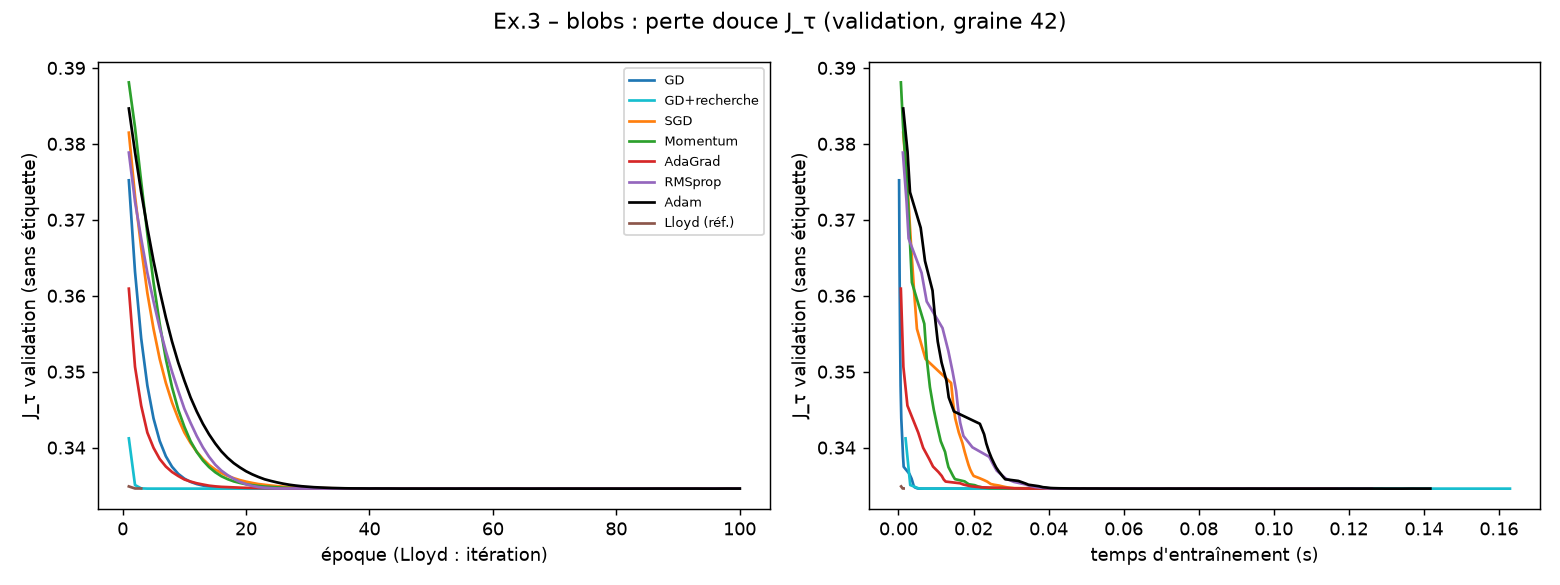

results/figures\ex3_blobs_points.png


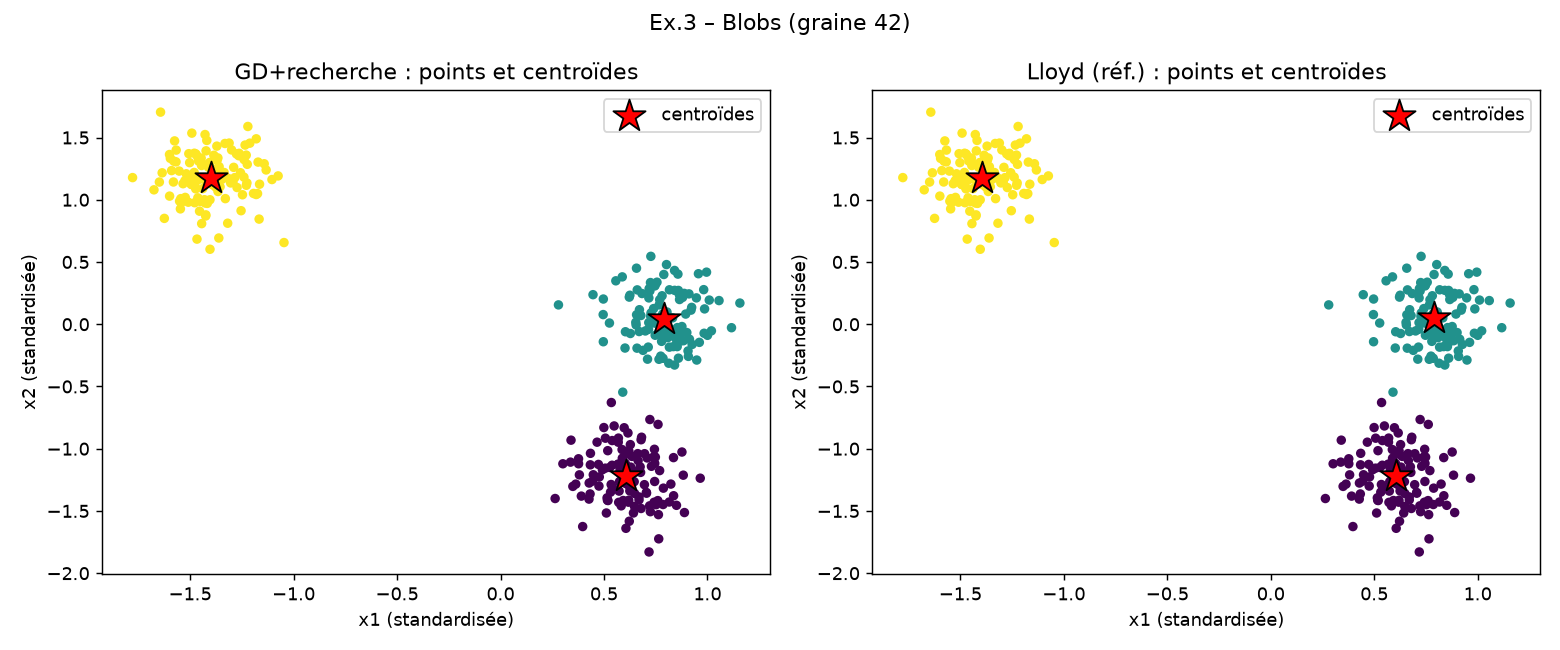

results/figures\ex3_blobs_sizes.png


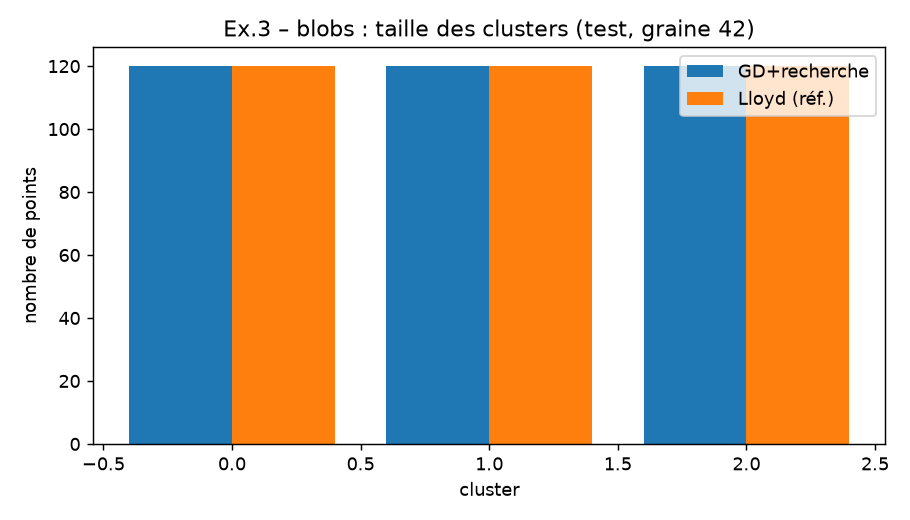

results/figures\ex3_fashion_centroids.png


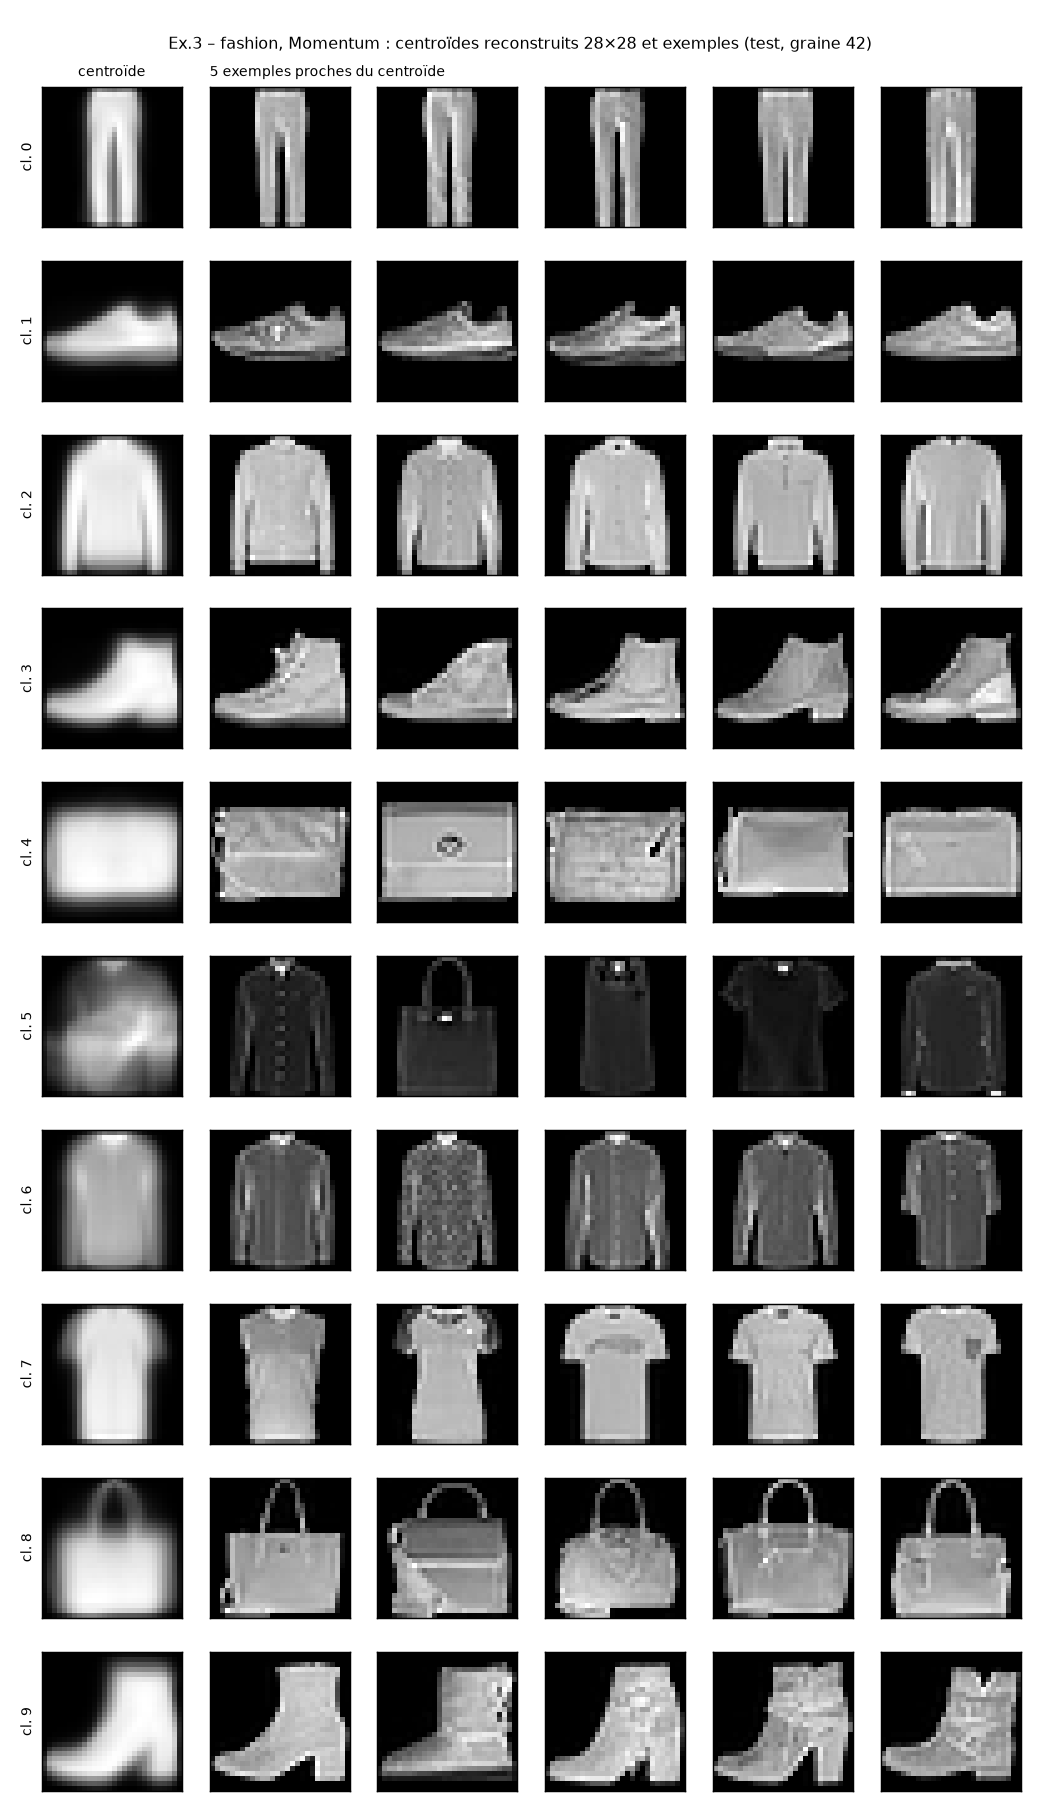

results/figures\ex3_fashion_curves.png


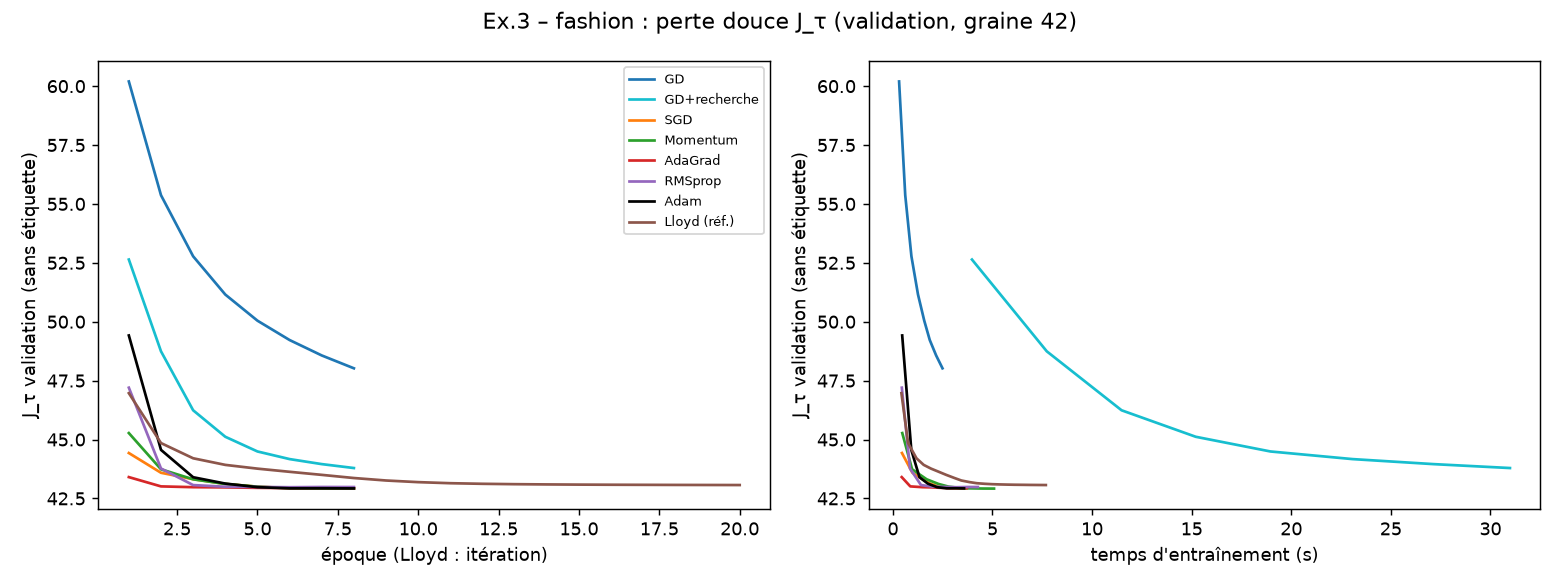

results/figures\ex3_fashion_pca.png


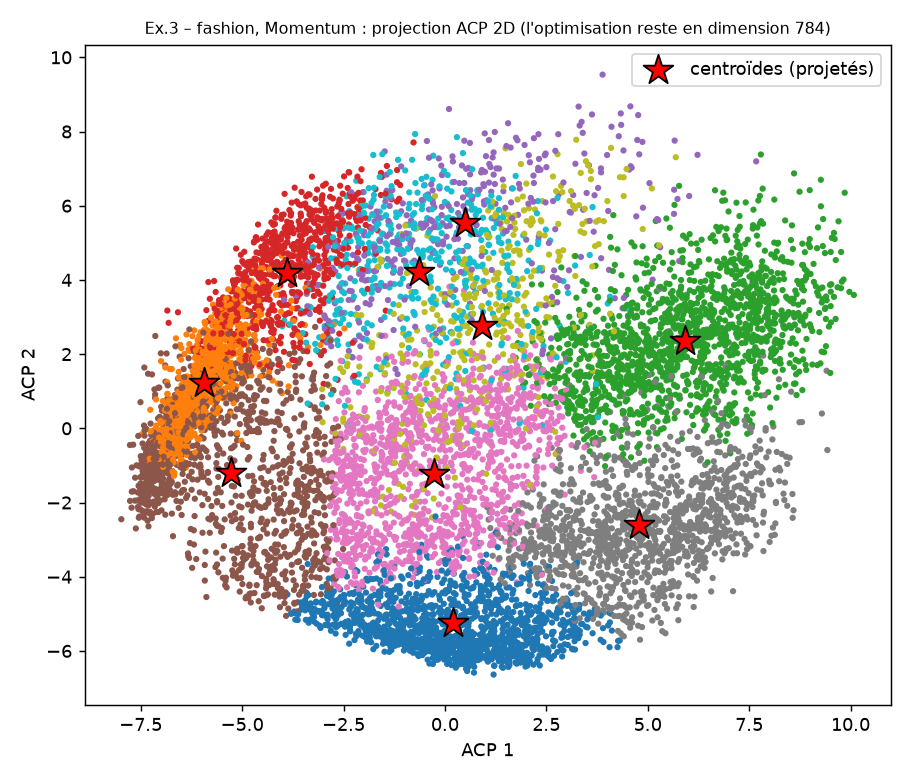

results/figures\ex3_fashion_sizes.png


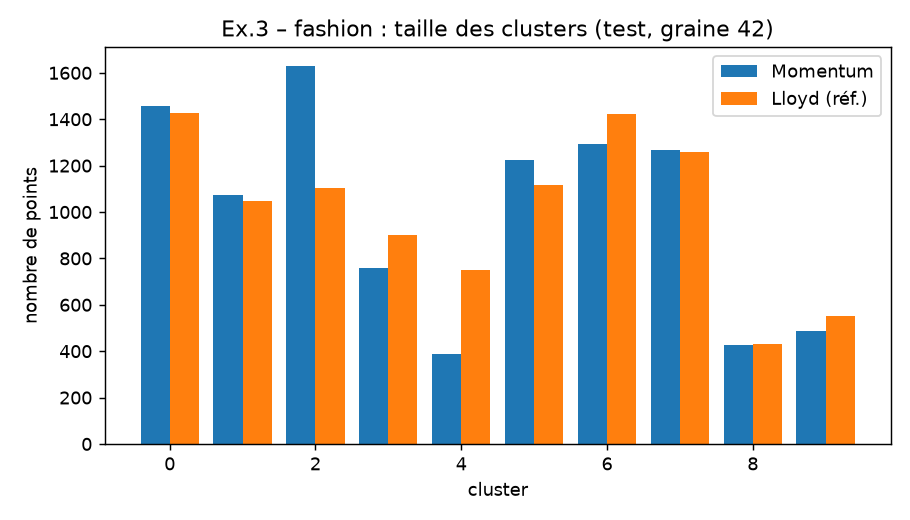

results/figures\ex3_mnist_centroids.png


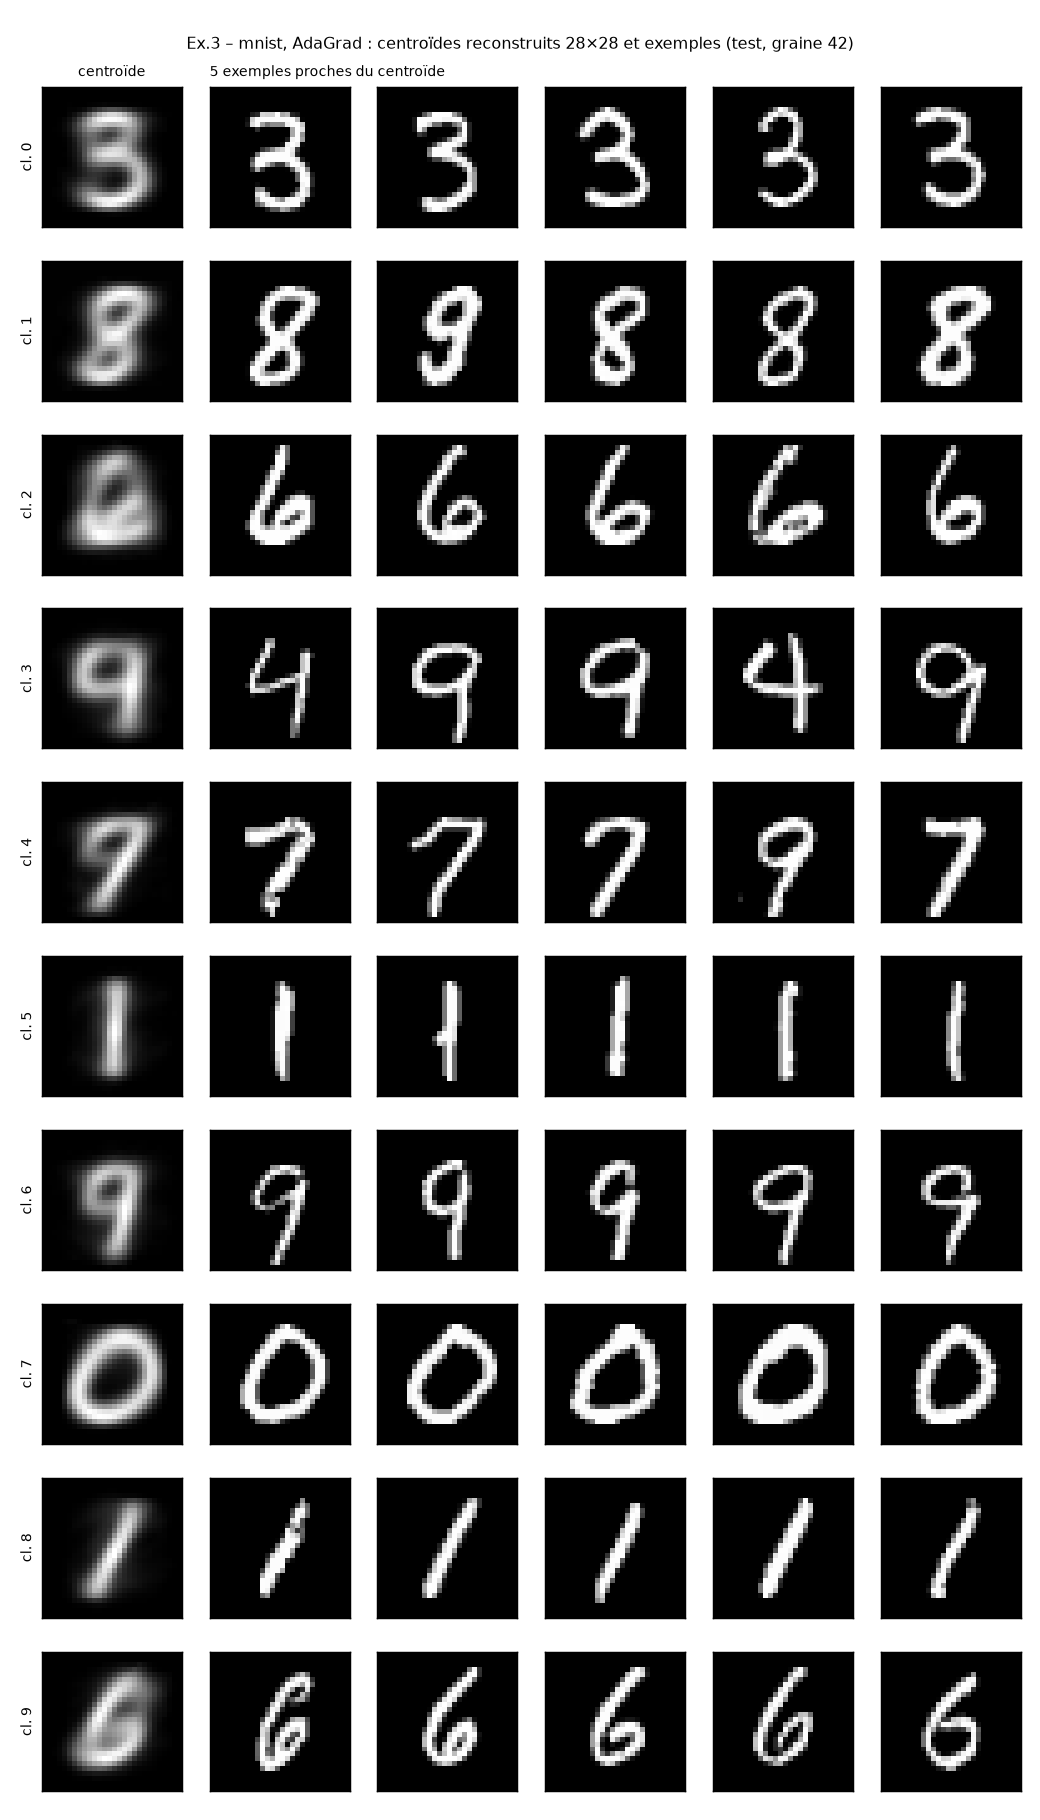

results/figures\ex3_mnist_curves.png


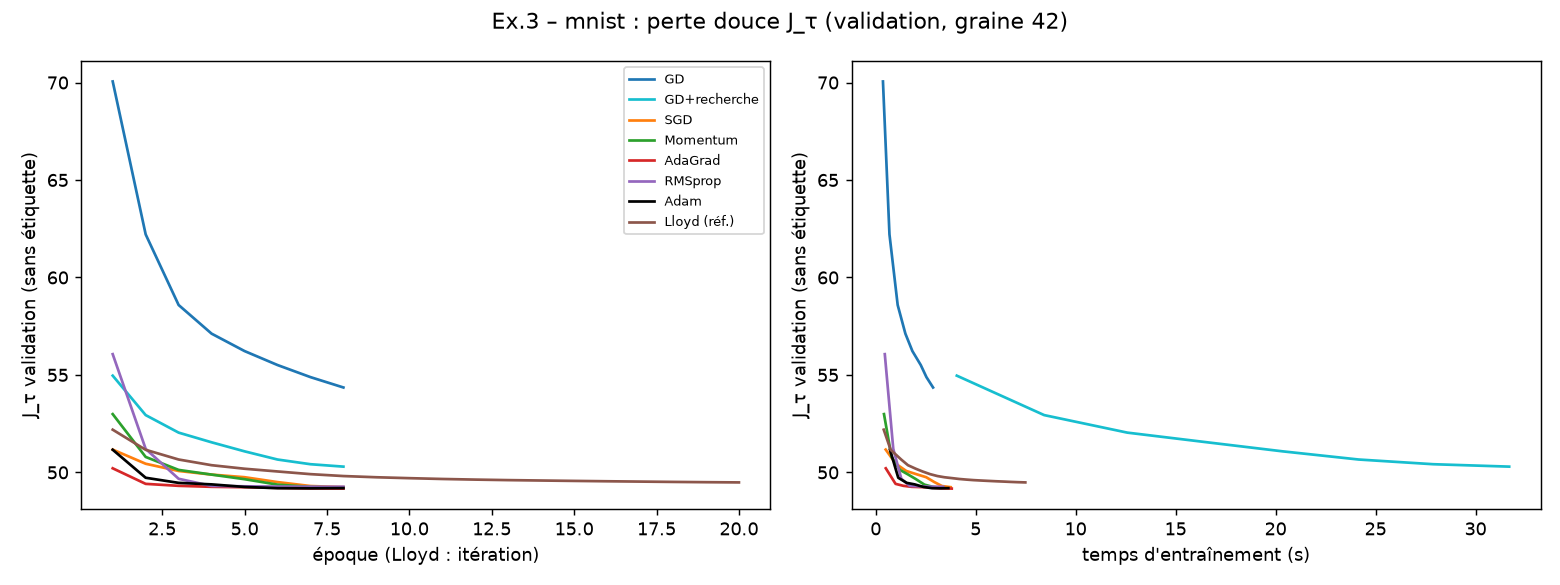

results/figures\ex3_mnist_pca.png


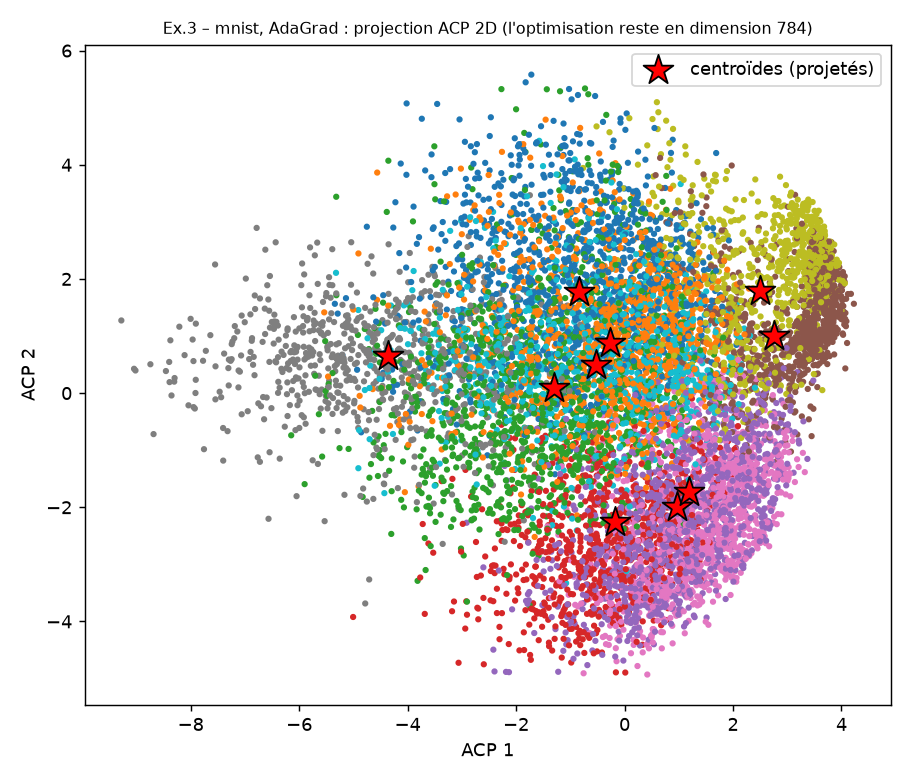

results/figures\ex3_mnist_sizes.png


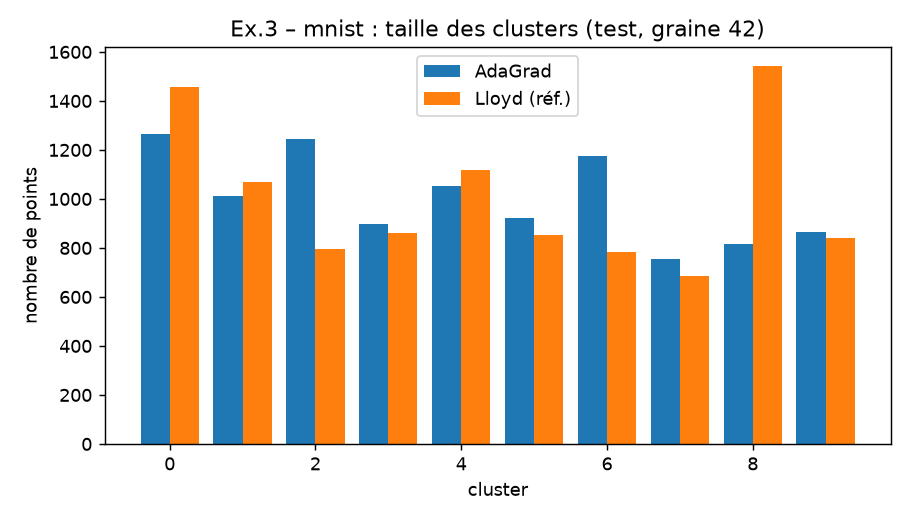

results/figures\ex3_wine_curves.png


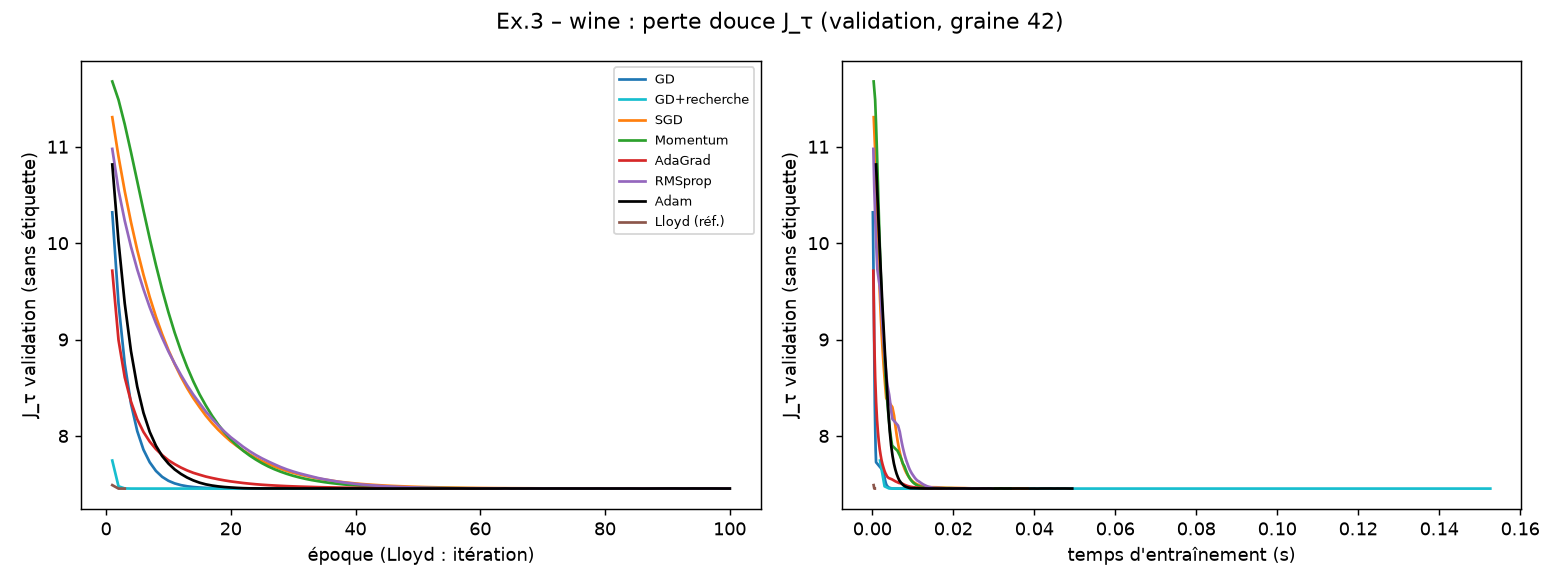

results/figures\ex3_wine_pca.png


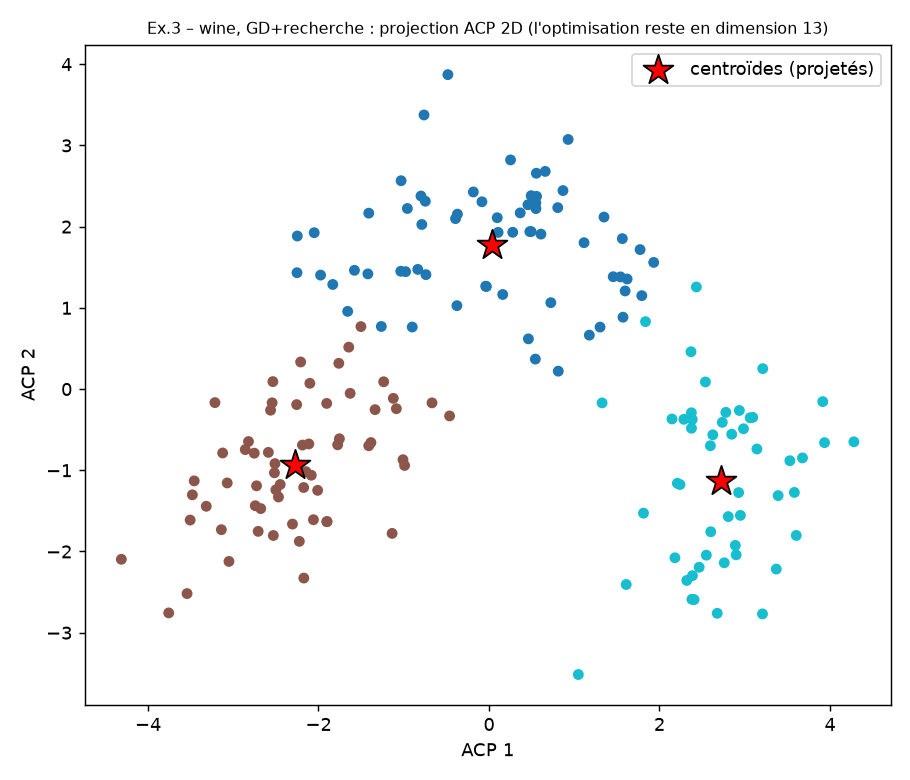

results/figures\ex3_wine_sizes.png


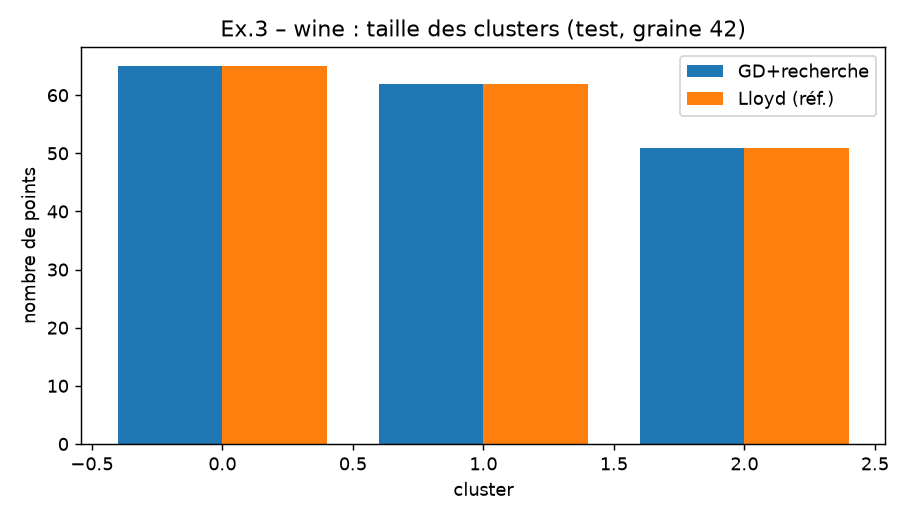

In [ ]:
import glob
from IPython.display import Image, display
for f in sorted(glob.glob("results/figures/ex3_*.png")):
    print(f); display(Image(filename=f, width=900))

## Export

In [ ]:
import shutil, os
shutil.make_archive("results", "zip", "results")
print("Créé :", os.path.abspath("results.zip"), "(%.1f Mo)" % (os.path.getsize("results.zip") / 1e6))

Créé : c:\Users\lenovo\Desktop\HADRI\results.zip (3.1 Mo)
